# KK1 - Analys av global tv-spelsförsäljning

Dataset: 'vgsales.csv'  Detta är taget från https://www.kaggle.com/datasets/gregorut/videogamesales?utm_source=chatgpt.com som i sin tur är en scrape från vgchartz.com.
Tema: global och regional försäljning av tv-spel  
Primära verktyg: pandas, numpy, matplotlib och seaborn

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Inläsning och första inspektion

Först läser jag in datan och gör en snabb inspektion. Det här steget handlar inte om att dra slutsatser än, utan om att förstå materialets form: antal rader, kolumner, datatyper, saknade värden och rimliga numeriska intervall.

In [56]:
df = pd.read_csv("data/vgsales.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [57]:
df.shape #Första antal rader andra kolumner.

(16598, 11)

In [58]:
missing_summary = df.isna().sum()
missing_summary
# Var det saknas värden, så lite år och publishers.

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [59]:
df.duplicated().sum() # Inga dubletter i data set:et.

np.int64(0)

Den första snabb inspektionen visar att datasetet har drygt 16000 rader och 11 kolumner. De viktigaste kolumnerna är regional och global försäljning. Två kolumner behöver tänka till på: `Year` och `Publisher`, eftersom vissa värden saknas och kanske användas direkt i analysen. Om jag vill göra någon typ av tidsdiagram måste jag komma ihåg att `Year` behöver fungera numeriskt på något sätt.

## 3. Datatvätt



In [60]:
clean_df = df.copy() # skapar en kopia av orginalet som kan "tvättas"

clean_df["Year"] = pd.to_numeric(clean_df["Year"], errors="coerce").astype("Int64") # gör om det till heltal
clean_df["Decade"] = (clean_df["Year"] // 10 * 10).astype("Int64") # Lägger till kolumnen Decade för att kunna visa årtienden istället.

clean_df[["Name", "Platform", "Year", "Decade"]].head()
#

,Name,Platform,Year,Decade
0,Wii Sports,Wii,2006,2000
1,Super Mario Bros.,NES,1985,1980
2,Mario Kart Wii,Wii,2008,2000
3,Wii Sports Resort,Wii,2009,2000
4,Pokemon Red/Pokemon Blue,GB,1996,1990


In [61]:
region_cols = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]  # Regionkolumnerna som tillsammans bör motsvara global försäljning.

clean_df["Regional_Total"] = clean_df[region_cols].sum(axis=1)  # Summerar regionerna rad för rad.
clean_df["Sales_Diff"] = clean_df["Global_Sales"] - clean_df["Regional_Total"]  # Räknar skillnaden mellan global och regional summa.
clean_df["Diff_OK"] = np.isclose(clean_df["Global_Sales"], clean_df["Regional_Total"], atol=0.03)  # Tillåter små avrundningsskillnader. Kontrollerar rad för rad om skillnaden är tillräckligt liten.

clean_df[["Global_Sales", "Regional_Total", "Sales_Diff", "Diff_OK"]].describe()


,Global_Sales,Regional_Total,Sales_Diff
count,16598.000000,16598.000000,16598.000000
mean,0.537441,0.537164,0.000277
std,1.555028,1.555151,0.005223
min,0.010000,0.000000,-0.020000
25%,0.060000,0.060000,0.000000
50%,0.170000,0.170000,0.000000
75%,0.470000,0.470000,0.000000
max,82.740000,82.740000,0.020000


In [62]:
clean_df["Diff_OK"].value_counts() #Räknar upp alla rader som är true och false om dom,
#hamnar inom ramen för vad som är tillåtet sannolikt att alla skillnader är avrundingar

Diff_OK
True    16598
Name: count, dtype: int64

Jag dubbelkollar att 'Global_Sales' verkar vara summan av regionerna. Skillnaderna är bara upp till 0.02 miljoner exemplar, vilket troligen beror på avrundning. Därför använder jag 'Global_Sales' vidare i analysen.

In [63]:
analysis_df = clean_df.dropna(subset=["Year", "Publisher"]).copy()

rows_removed = len(clean_df) - len(analysis_df)
rows_removed, len(analysis_df)

(307, 16291)

In [64]:
print(f"Antal borttagna rader: {rows_removed}")
print(f"Antal rader kvar: {len(analysis_df)}")

Antal borttagna rader: 307
Antal rader kvar: 16291


För analysdelen tar jag bort rader där 'Year', 'Genre' eller 'Publisher' saknas. Jag gör det i en separat analys-DataFrame, att arbeta med. Motiveringen är att tidsanalys, genreanalys och publisheranalys kräver dessa fält "rena". Eftersom antalet borttagna rader är litet jämfört med hela datasetet så borde det inte förändra huvudmönstren. Jag blev lite förvirrad först att det blev en annan summa bortagna än rader som saknade värde
men vissa som saknade Year saknade även  publisher.

# Utforskning genom visualisering

Här använder jag olika diagramtyper beroende av frågan jag ställer om datan, och väljer diagram efter vad betraktaren ska kunna jämföra.


### Fråga 1: Vilka genrer dominerar global försäljning?

Här vill jag rangordna kategorier. Därför väljer jag ett horisontellt stapeldiagram. Det gör det lätt att jämföra genrer och läsa etiketterna.

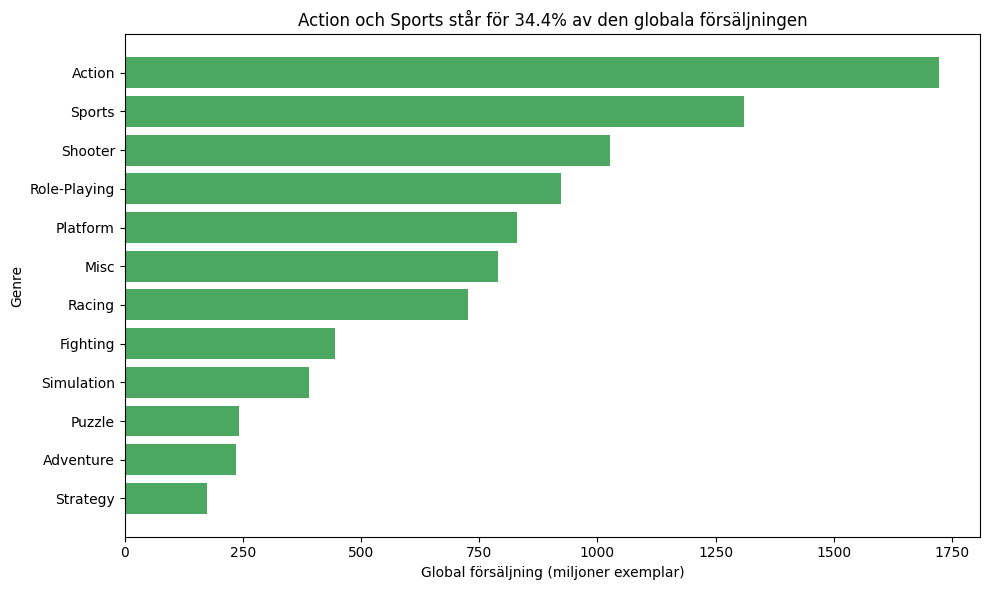

In [65]:
genre_sales = (
    analysis_df.groupby("Genre", as_index=False)["Global_Sales"]
    .sum()
    .sort_values("Global_Sales", ascending=True)
)

action_sports_sales = genre_sales.loc[
    genre_sales["Genre"].isin(["Action", "Sports"]),
    "Global_Sales"
].sum()

total_global_sales = genre_sales["Global_Sales"].sum()
action_sports_share = action_sports_sales / total_global_sales * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(genre_sales["Genre"], genre_sales["Global_Sales"], color="#4CA860")

ax.set_title(f"Action och Sports står för {action_sports_share:.1f}% av den globala försäljningen")
ax.set_xlabel("Global försäljning (miljoner exemplar)")
ax.set_ylabel("Genre")
ax.set_xlim(left=0)

plt.tight_layout()
plt.show()

Diagrammet visar att global försäljning är ojämnt fördelad mellan genrer. Action och Sports ligger tydligt högst, medan Strategy och Adventure ligger betydligt lägre.

En viktig begränsning är att genre-kolumnen bara verkar ha en genre per spel. Många spel kan passa i flera genrer, men datasetet tvingar in varje spel i en huvudkategori. Det kan göra att breda genrer som Action samlar många olika typer av spel, medan smalare genrer ser mindre ut.

Min tolkning är därför inte bara att “Action säljer mest”, utan att spel med action-, shooter- eller rollspelselement verkar vara starka i datasetet. Sports sticker också ut som en stor egen kategori, troligen eftersom sportspel ofta är tydligare avgränsade som genre.

En annan viktig begränsning är att en rad verkar vara ett spel på en specifik plattform, inte ett unikt spel som helhet. Samma spel kan därför förekomma flera gånger om det släppts på flera plattformar. Det gör att spel och genrer som ofta fungerar på många plattformar kan få större total försäljning i analysen. Sportspel är ett tydligt exempel, eftersom samma årliga titel ofta släpps på flera konsoler och ibland även PC.

### Fråga 2: Global försäljning över tid i datasetet?

Jag väljer linjediagram eftersom frågan handlar om utveckling over tid.

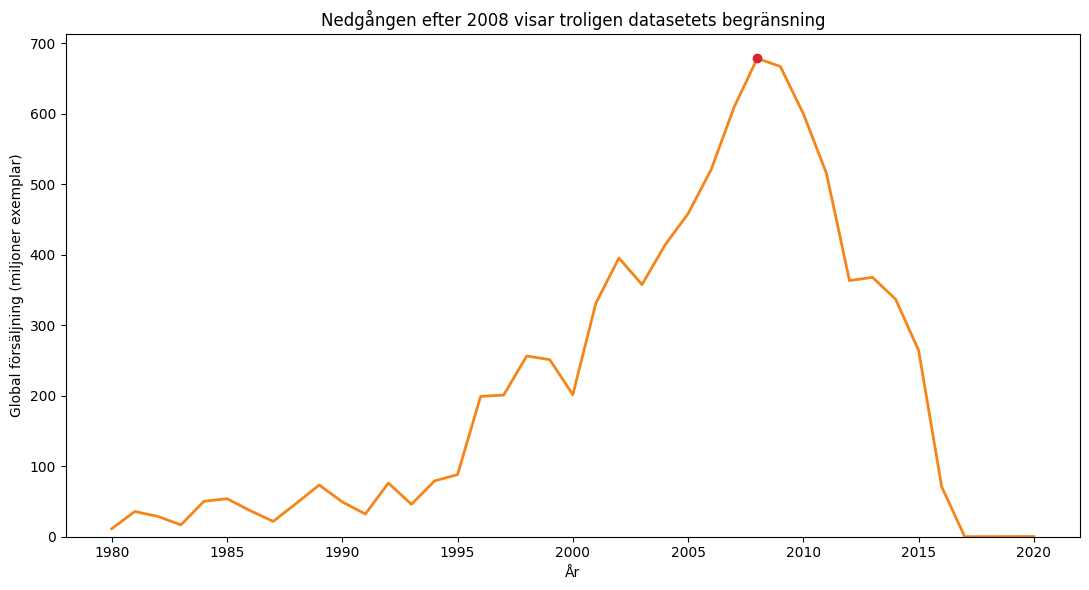

In [66]:
yearly_sales = (
    analysis_df.groupby("Year", as_index=False)["Global_Sales"]
    .sum()
    .sort_values("Year")
)

peak_year = yearly_sales.loc[yearly_sales["Global_Sales"].idxmax()]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(yearly_sales["Year"], yearly_sales["Global_Sales"], color="#F58518", linewidth=2)
ax.scatter(peak_year["Year"], peak_year["Global_Sales"], color="#D62728", zorder=3)

ax.set_title("Nedgången efter 2008 visar troligen datasetets begränsning")
ax.set_xlabel("År")
ax.set_ylabel("Global försäljning (miljoner exemplar)")
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

Diagrammet visar att försäljningen i datasetet toppar runt 2008 och sedan sjunker kraftigt. Jag tolkar inte det som att spelmarknaden faktiskt krympte på samma sätt. Eftersom spelmarknaden fortsatt växa globalt tyder nedgången snarare på att datasetet blir mindre komplett för senare år.

### Fråga 3: Vilka genrer skiljer sig mest mellan Nordamerika, Europa och Japan?



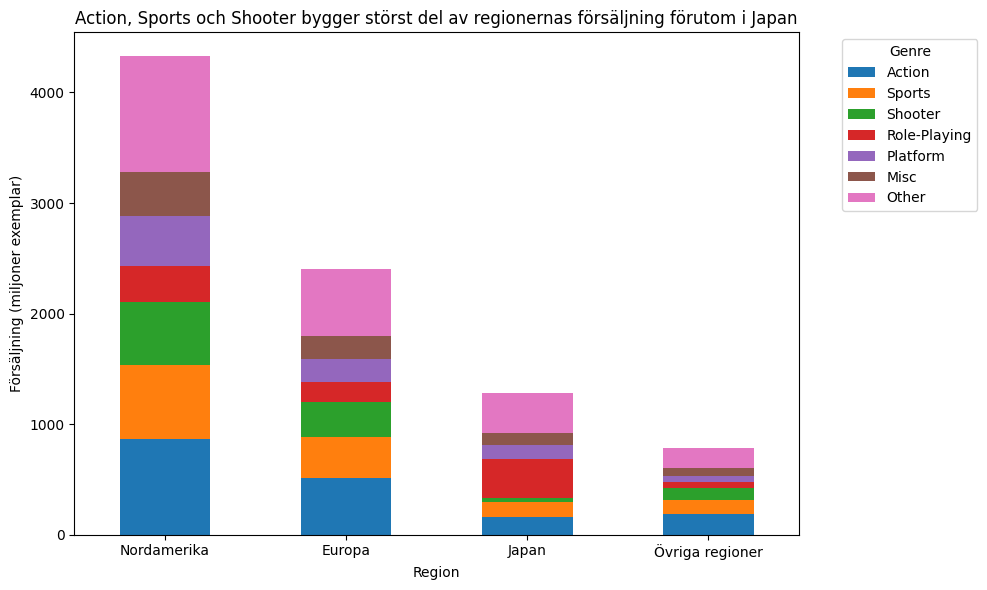

In [67]:
region_cols = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]

region_genre = analysis_df.groupby("Genre")[region_cols].sum()

top_genres = (
    region_genre.sum(axis=1)
    .sort_values(ascending=False)
    .head(6)
    .index
)

region_genre_grouped = region_genre.loc[top_genres].copy()
region_genre_grouped.loc["Other"] = region_genre.drop(top_genres).sum()

plot_df = region_genre_grouped.T

plot_df = plot_df.rename(index={
    "NA_Sales": "Nordamerika",
    "EU_Sales": "Europa",
    "JP_Sales": "Japan",
    "Other_Sales": "Övriga regioner"
})

# Sortera genrer efter total storlek, men lägg restkategorin Other överst i stapeln.
genre_order = plot_df.drop(columns="Other").sum().sort_values(ascending=False).index.tolist()
genre_order.append("Other")

plot_df = plot_df[genre_order]

fig, ax = plt.subplots(figsize=(10, 6))

plot_df.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title("Action, Sports och Shooter bygger störst del av regionernas försäljning förutom i Japan")
ax.set_xlabel("Region")
ax.set_ylabel("Försäljning (miljoner exemplar)")
ax.set_ylim(bottom=0)
ax.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Diagrammet visar att Nordamerika, Europa och övriga regioner har ganska liknande genreprofil i försäljningen. Action, Sports och Shooter tar stor plats i alla tre. Japan sticker däremot ut: Role-Playing tar en mycket större andel där, framför allt på bekostnad av Shooter.

Eftersom diagrammet använder absoluta tal syns också att Nordamerika står för klart störst försäljning i datasetet. Det kan betyda att den nordamerikanska marknaden faktiskt är störst i datan, men det kan också tyda på att datasetet är mer komplett eller mer inriktat på nordamerikansk försäljning. Därför tolkar jag regionala skillnader försiktigt.

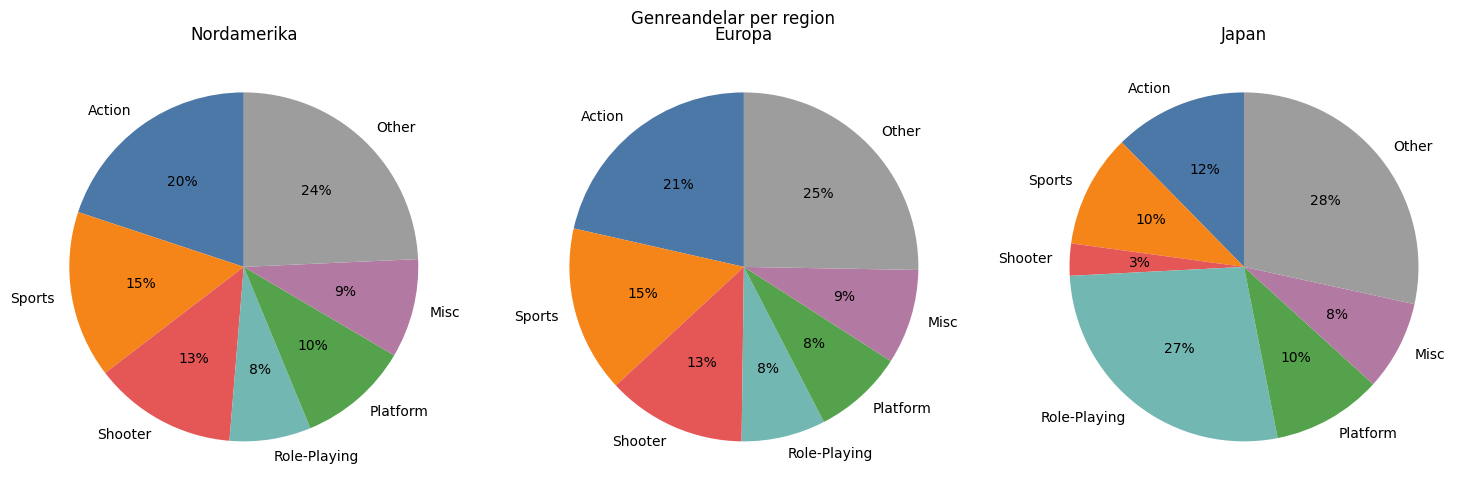

In [70]:
region_cols = ["NA_Sales", "EU_Sales", "JP_Sales"]

region_genre = analysis_df.groupby("Genre")[region_cols].sum()

top_genres = (
    region_genre.sum(axis=1)
    .sort_values(ascending=False)
    .head(6)
    .index
    .tolist()
)

region_genre_grouped = region_genre.loc[top_genres].copy()
region_genre_grouped.loc["Other"] = region_genre.drop(top_genres).sum()

genre_order = top_genres + ["Other"]

genre_colors = {
    "Action": "#4C78A8",
    "Sports": "#F58518",
    "Shooter": "#E45756",
    "Role-Playing": "#72B7B2",
    "Platform": "#54A24B",
    "Misc": "#B279A2",
    "Other": "#9D9D9D",
}

region_names = {
    "NA_Sales": "Nordamerika",
    "EU_Sales": "Europa",
    "JP_Sales": "Japan",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, region in zip(axes, region_cols):
    values = region_genre_grouped.loc[genre_order, region]
    colors = [genre_colors[genre] for genre in genre_order]

    ax.pie(
        values,
        labels=genre_order,
        autopct="%1.0f%%",
        startangle=90,
        colors=colors
    )
    ax.set_title(region_names[region])

plt.suptitle("Genreandelar per region")
plt.tight_layout()
plt.show()

Jag behåller också pie charts för att visa andelen genrer inom varje region. De gör det lätt att se regionernas interna genreprofil, till exempel att Role-Playing tar större plats i Japan.

Däremot visar pie charts inte relationen mellan regionernas totala försäljning. En lika stor tårtbit i Japan och Nordamerika betyder alltså inte lika många sålda spel, eftersom regionernas totala försäljning skiljer sig mycket. Därför använder jag stacked bar chart för absoluta nivåer och pie charts för andelar.

Misc är en genre i datasetet och betyder ungefär blandade eller svårkategoriserade spel. Den ska inte blandas ihop med Other, som jag själv skapar i diagrammet för att samla mindre genrer.

### Fråga 4: Hur ser topp 10 ute bland de flest sålda spel ut globalt?

Jag väljer stapeldiagram för topp 10 eftersom frågan är väldigt enkel handlar om att jamföra namngivna spel och upptäcka outliers.

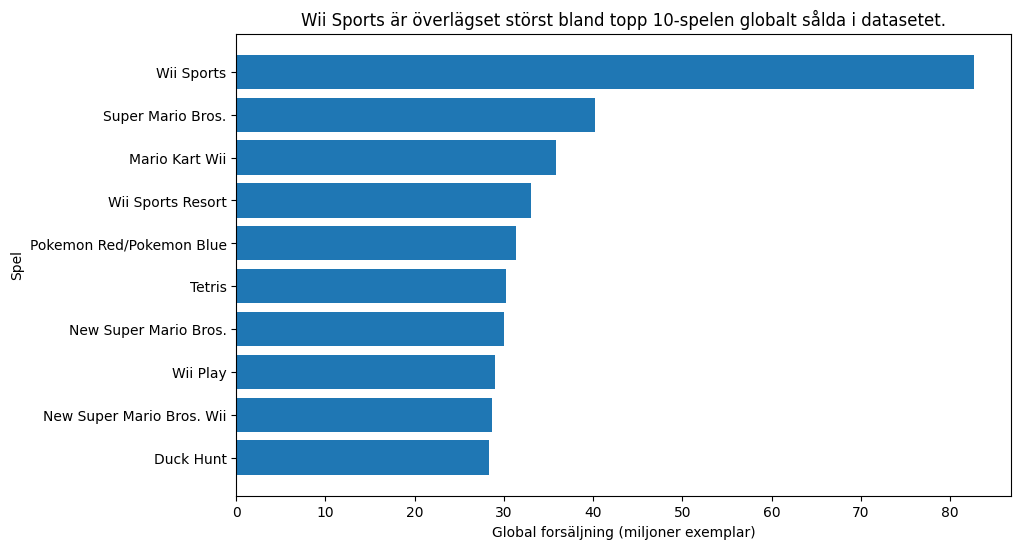

In [75]:
top_games = analysis_df.nlargest(10, "Global_Sales").sort_values("Global_Sales", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_games["Name"], top_games["Global_Sales"])
ax.set_title("Wii Sports är överlägset störst bland topp 10-spelen globalt sålda i datasetet.")
ax.set_xlabel("Global forsäljning (miljoner exemplar)")
ax.set_ylabel("Spel")
ax.set_xlim(left=0)

plt.show()

Wii Sports sticker ut tydligt jämfört med resten av topp 10. En möjlig förklaring är att spelet följde med Wii-konsolen i många marknader. Det gör att försäljningen inte är helt jämförbar med spel som såldes separat.